# Phần 2: Phân cụm Khách hàng theo Mô hình RFM
Sử dụng thuật toán **K-Means Clustering** để phân đoạn khách hàng thành các nhóm đặc trưng dựa trên:
- **Recency (R):** Số ngày kể từ lần mua cuối cùng.
- **Frequency (F):** Tổng số đơn hàng.
- **Monetary (M):** Tổng số tiền đã chi tiêu.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Nạp và Chuẩn bị dữ liệu
Dùng lại các bảng orders, order_items, payments và customers.

In [3]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

# Lọc đơn hàng thành công và ghép bảng
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(orders_delivered['order_purchase_timestamp'])

# Tính tổng tiền mỗi đơn hàng
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Merge
df = pd.merge(orders_delivered, order_payments, on='order_id', how='inner')
df = pd.merge(df, customers, on='customer_id', how='inner')

print(f"Số lượng đơn hàng: {len(df)}")
df.head(3)

Số lượng đơn hàng: 96477


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


## 2. Tính toán RFM (Recency, Frequency, Monetary)
Nhóm theo `customer_unique_id` để biết mỗi cá nhân có hành vi như thế nào.

In [4]:
# Mốc thời gian hiện tại (Lấy ngày giao dịch cuối cùng + 1 ngày)
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Tính RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                                 # Frequency
    'payment_value': 'sum'                                                 # Monetary
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Xem phân phối của RFM
rfm.describe()

,Recency,Frequency,Monetary
count,93357.000000,93357.000000,93357.000000
mean,237.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.560000
max,695.000000,15.000000,13664.080000


## 3. Xử lý ngoại lệ (Outliers) và Chuẩn hóa (Scaling)
Dữ liệu Monetary và Frequency thường bị lệch phải (right-skewed), ta sử dụng `Log Transformation` để phân phối chuẩn hơn, sau đó dùng `StandardScaler`.

In [5]:
# Log Transformation (Cộng thêm 1 để tránh log(0))
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency'] = np.log(rfm_log['Recency'] + 1)
rfm_log['Frequency'] = np.log(rfm_log['Frequency'] + 1)
rfm_log['Monetary'] = np.log(rfm_log['Monetary'] + 1)

# StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,-0.470385,-0.170191,0.288235
1,-0.442302,-0.170191,-1.719767
2,1.202051,-0.170191,-0.322526
3,0.651914,-0.170191,-1.151681
4,0.536031,-0.170191,0.690987


## 4. Áp dụng K-Means Clustering
Sử dụng phương pháp Elbow để kiểm tra, nhưng dựa trên yêu cầu kinh doanh, ta sẽ ấn định `k=4` (ví dụ: Khách VIP, Khách Tiềm năng, Khách Mới, Khách Ngủ quên).

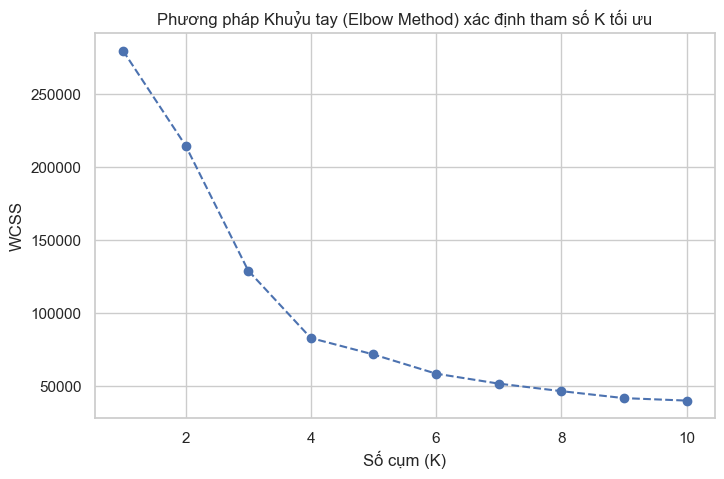

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Phương pháp Khuỷu tay (Elbow Method) xác định tham số K tối ưu')
plt.xlabel('Số cụm (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Gán nhãn cụm vào dataframe gốc
rfm['Cluster'] = kmeans.labels_

# Phân tích đặc điểm từng cụm (Tính trung bình R, F, M của mỗi cụm)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_summary)


        Recency Frequency Monetary       
           mean      mean     mean  count
Cluster                                  
0        272.48      1.00   295.78  32185
1        287.33      1.00    68.21  42287
2        220.29      2.11   308.59   2801
3         42.02      1.00   133.91  16084


## 5. Đặt tên (Profiling) và Trực quan hóa Khách hàng

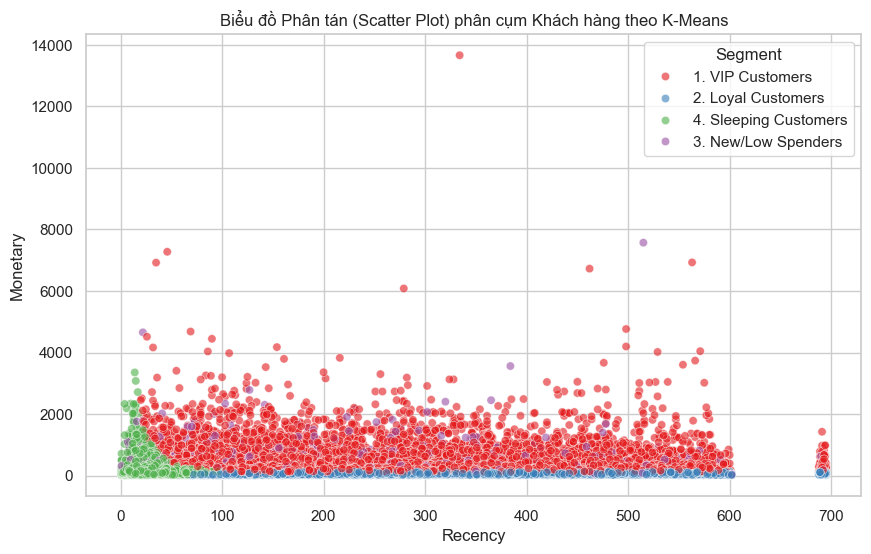

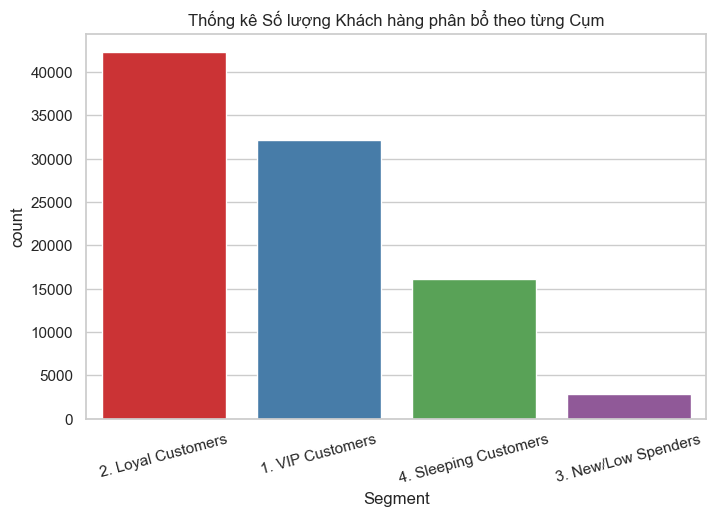

In [8]:
# Đặt tên cho các cụm (Lưu ý: Tùy vào kết quả cluster_summary ở trên, 
# nhãn số cụm có thể hoán đổi. Đoạn này tự động map dựa trên xếp hạng Monetary)

sorted_clusters = cluster_summary.index.tolist()
# Giả sử:
# Hạng 1 (Tiêu nhiều nhất): VIP Customers
# Hạng 2: Loyal Customers
# Hạng 3: New / Low Spenders
# Hạng 4 (Tiêu ít, Recency cao): Churned / Sleeping

cluster_names = {
    sorted_clusters[0]: '1. VIP Customers',
    sorted_clusters[1]: '2. Loyal Customers',
    sorted_clusters[2]: '3. New/Low Spenders',
    sorted_clusters[3]: '4. Sleeping Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Trực quan hóa bằng Scatter Plot (Recency vs Monetary)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='Set1', alpha=0.6)
plt.title('Biểu đồ Phân tán (Scatter Plot) phân cụm Khách hàng theo K-Means')
plt.show()

# Phân bổ số lượng khách hàng theo từng nhóm
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='Set1')
plt.title('Thống kê Số lượng Khách hàng phân bổ theo từng Cụm')
plt.xticks(rotation=15)
plt.show()

> **📌 Insight (Giá trị trọn đời - CLV):** Nhóm **VIP Customers** và **Loyal Customers** là những người mang lại giá trị trọn đời (CLV) cao nhất cho doanh nghiệp. Mặc dù số lượng của họ rất ít, mức chi tiêu của họ lại vượt trội. Doanh nghiệp cần xây dựng chương trình chăm sóc đặc biệt (ví dụ: tặng mã giảm giá độc quyền, miễn phí vận chuyển) để giữ chân nhóm này. Đồng thời, nhóm **Sleeping Customers** có Recency rất cao, cần chạy các chiến dịch Remarketing để "đánh thức" họ quay lại mua hàng.